# Machine Learning: Exercise session 11

In this exercise session we will continue on the topic of neural networks.

In the first theoretical exercise, we construct neural networks by hand to solve simple logic gate problems.

The second practical exercise is about convolutional neural networks (CNN) and continues where the last exercise session left off, using the same fashion MNIST dataset.

## Exercise 1: Expressiveness of Neural Networks

In this exercise, we consider neural networks built for two boolean predictors $X_1$ and $X_2$ (i.e., $X_1, X_2 \in \{0,1\}$) and a bolean targer $Y\in\{0,1\}$.

The considered networks have sigmoid activation functions
$$\sigma(z)=\dfrac{1}{1+\exp(-z)}, \;\; \forall z \in \mathbb{R}.$$

Since the sigmoid function maps to $(0,1)$, we trat the (single) network output $\hat{Y}\in(0,1)$ as predicting the value $1$ if $\hat{Y}\geq 0.5$ and $0$ otherwise.

1. Consider the following dataset

| X1 | X2 | Y |
|:--:|:--:|:-:|
|  0 |  0 | 0 |
|  0 |  1 | 1 |
|  1 |  0 | 1 |
|  1 |  1 | 1 |

Design a neural network with no hidden layers to predict $Y$. Draw the neural network architecture and specify the value of the weights.

2. Consider the following dataset

| X1 | X2 | Y |
|:--:|:--:|:-:|
|  0 |  0 | 0 |
|  0 |  1 | 0 |
|  1 |  0 | 0 |
|  1 |  1 | 1 |

Design a neural network with no hidden layers to predict $Y$. Draw the neural network architecture and specify the value of the weights.

3. Consider the following dataset

| X1 | X2 | Y |
|:--:|:--:|:-:|
|  0 |  0 | 0 |
|  0 |  1 | 1 |
|  1 |  0 | 1 |
|  1 |  1 | 0 |

Design a neural network with one hidden layer to predict $Y$. Draw the neural network architecture and specify the value of the weights.

### Solution
Please refer to the handwritten notes.

In [1]:
import numpy as np

def sigmoid(z):
    return 1/(1+np.exp(-z))

In [2]:
sigmoid(0)

0.5


### Useful link
Visual understanding of how neural networks work: https://playground.tensorflow.org/

## Exercise 2: Classifying images with CNNs

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

### 2.0. Importing the data

* Load the fashion mnist data and follow the same standardisation procedure as in Exercise session 10.

In [4]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [5]:
print(X_train_full.shape)
print(X_train_full.dtype)

(60000, 28, 28)
uint8


In [6]:
X_train_scaled = X_train_full / 255.0
X_test_scaled = X_test / 255.0
X_train_scaled.dtype

dtype('float64')

In [7]:
X_valid = X_train_scaled[:5000] #or better: use a train-test split
X_train = X_train_scaled[5000:]
y_valid = y_train_full[:5000]
y_train = y_train_full[5000:]

X_test = X_test_scaled

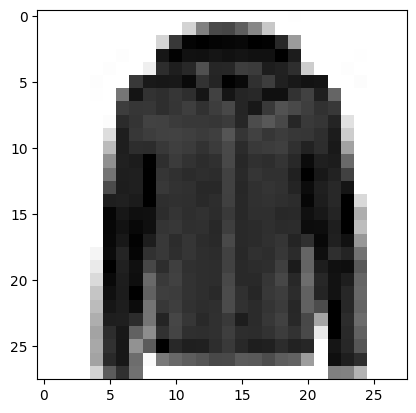

In [8]:
plt.imshow(X_train[0], cmap="binary");

In [9]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", 
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [10]:
class_names[2]

'Pullover'

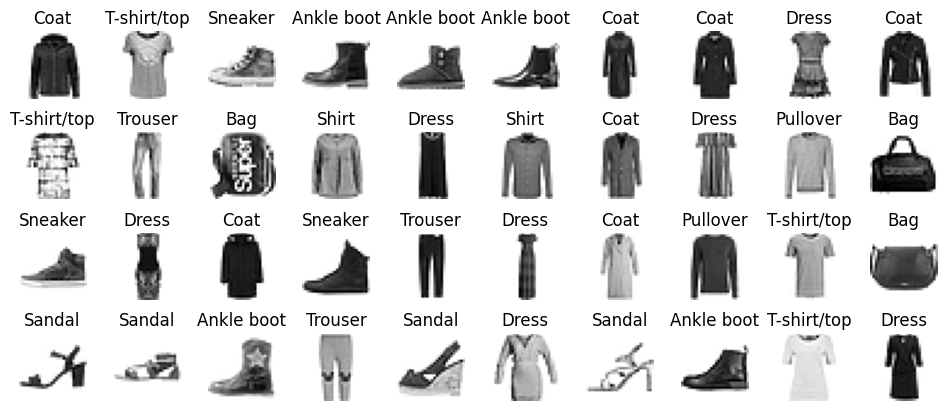

In [11]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary")
        plt.title(class_names[y_train[index]], fontsize=12)
        plt.axis('off')
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

### 2.1 Convolutional neural networks

In this problem we show how to create and train a convolutional neural network to the fashion MNIST dataset.

* We first have to adjust the predictor dataset by adding a third dimension. In CNN, each image is encoded as with three dimension (height, width, depth), where depth represents the color scales. Black and white images only have the scale of greys, so depth = 1. Color images, have the red, green, and blue scales (RGB), so depth = 3.

In [12]:
# image shape
X_train[0].shape

(28, 28)

In [13]:
X_train = np.expand_dims(X_train, axis=-1)
X_valid = np.expand_dims(X_valid, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [14]:
# image shape
X_train[0].shape

(28, 28, 1)

In [15]:
X_train.shape

(55000, 28, 28, 1)

* We begin by building the CNN architecture. Choose filter sizes of 5 by 5 for the first two convolution layers and of 3 by 3 for the third. Specify some values for the other architecture hyperparameters as well, and understand what they do.

In [16]:
model = keras.models.Sequential([
    keras.layers.Conv2D(filters=64, # number of filters
                        kernel_size=(5,5), # height and width of each filter
                        activation="relu",
                        #padding="same", # with strides = 1, to ensure input and output layers have same dimensions if needed
                        input_shape = [28,28,1]),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(filters=128, kernel_size=(5,5), activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation="relu"),
    keras.layers.MaxPooling2D(pool_size=2),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(units=10, activation='softmax'),
])

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 24, 24, 64)        1664      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 12, 12, 64)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 8, 128)         204928    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 4, 4, 128)        0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 2, 2, 128)         147584    
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 1, 1, 128)        0

* Compute the number of trainable parameters and the output shape of the second convolution layer. One can use the model "summary" to verify the answers.

In [18]:
print("Nb. Parameters: ", (5*5*64 + 1) * 128 )
print("Output shape:   ", ("batch_size", 12-5+1, 12-5+1, 128) )

Nb. Parameters:  204928
Output shape:    ('batch_size', 8, 8, 128)


* We compile the model by defining the loss, an optimizer and metrics.

In [19]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)

model.compile(loss="sparse_categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"])

* We train the model saving the logs in variable named `cnn_history`. Callbacks can help controlling the fitting procedure.

In [ ]:
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath="checkpoints/cnn_epoch={epoch:02d}_val_accuracy={val_accuracy:.2f}.h5")
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1)

cnn_history = model.fit(x = X_train, y = y_train,
                        validation_data = (X_valid, y_valid),
                        epochs = 50,
                        batch_size = 64,
                        callbacks=[early_stopping_cb, checkpoint_cb])

#model.save("checkpoints/cnn_trained.h5")

In [21]:
model = keras.models.load_model("checkpoints/cnn_trained.h5")

* Let us evaluate the model performance and make some predictions

In [22]:
model.evaluate(X_train, y_train);

1719/1719 [==============================] - 14s 8ms/step - loss: 0.1292 - accuracy: 0.9544


In [23]:
model.evaluate(X_valid, y_valid);

157/157 [==============================] - 2s 9ms/step - loss: 0.2302 - accuracy: 0.9180


In [24]:
model.evaluate(X_test, y_test);

313/313 [==============================] - 3s 9ms/step - loss: 0.2560 - accuracy: 0.9119


In [25]:
indices = np.arange(1, 11)
X_new = X_test[indices]
y_new = y_test[indices]
np.argmax(model.predict(X_new), axis=-1)

1/1 [==============================] - 0s 100ms/step


array([2, 1, 1, 6, 1, 4, 6, 5, 7, 4], dtype=int64)

In [26]:
indices = np.arange(1, 11)
X_new = X_test[indices]
y_new = y_test[indices]
y_pred = np.argmax(model.predict(X_new), axis=-1)
print("Predicted classes:", y_pred)
print("True classes     :", y_new)

1/1 [==============================] - 0s 18ms/step
Predicted classes: [2 1 1 6 1 4 6 5 7 4]
True classes     : [2 1 1 6 1 4 6 5 7 4]


In [27]:
class_names[y_pred[1]]

'Trouser'

* One can inspect what some of the the activations of the first convolution layer look like as images. What do you observe?

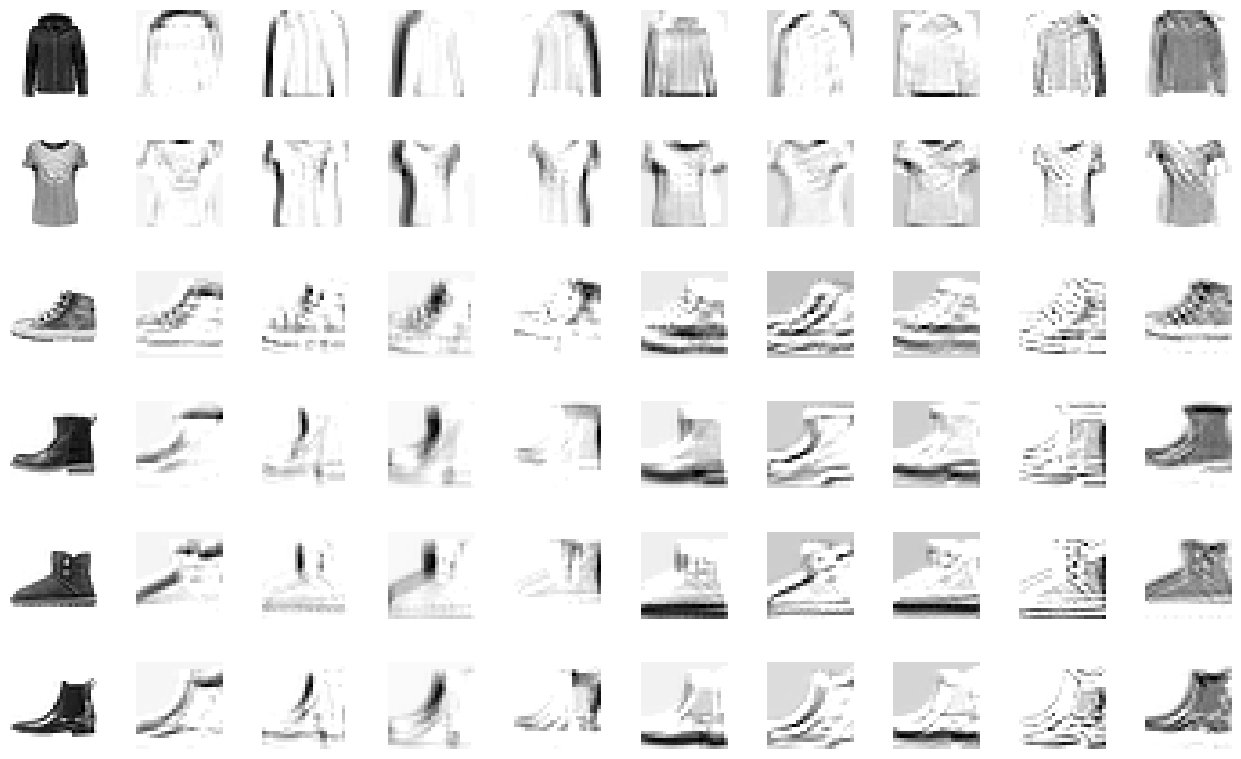

In [28]:
conv1 = model.get_layer('conv2d')

n_rows = 6
n_cols = 10
plt.figure(figsize=(n_cols * 1.6, n_rows * 1.6))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        if col==0:
            # Original image
            plt.imshow(X_train[row], cmap="binary")
        else:
            # `col`th activation of `conv1`
            plt.imshow(conv1(X_train[row:(row+1)])[0,:,:,(col-1)], cmap = "binary")
        plt.axis('off')
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

## 3. Additional topics

### Does `model.compile` initialize all the weights?
Notice that once you create a model with `keras.models.Sequential` for example, all the weights are initialized.
When you compile a model with `model.compile` you just set:
- a loss function,
- an optimizer,
- optionally, some additional metrics.

If you have a model that you already trained and you wish, for example, to change the learning rate of the optimizer, you can just compile the model again. Nothing happens to the pre-existing weights.

### Fine-tuning neural networks (this part may be skipped)
Neural networks have many hyperparameters, such as the number of hidden layers, nodes per hidden layer, learning rate, dropout rate, etc.
`Keras Tuner` is a Python package that helps you build a grid of hyperparameter and run a search across these.

In [ ]:
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

In [ ]:
def build_model(hp):
    '''
    Hyperparameters -> Keras compiled model
    Produces a Keras compiled model, taking one combination of parameters in hp
    '''
    
    model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(units=300, activation="relu"),
    keras.layers.Dense(units=100, activation="relu"),
    keras.layers.Dropout(rate=hp.get("dropout_rate")),
    keras.layers.Dense(units=10, activation="softmax")
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=hp.get("learning_rate"))
    model.compile(loss = "sparse_categorical_crossentropy",
                  optimizer = optimizer,
                  metrics= ["accuracy"])
    
    return model
    

In [ ]:
hp = HyperParameters()
hp.Choice('learning_rate', [1e-1, 1e-3])
hp.Choice('dropout_rate', [0.0, 0.2]);

In [ ]:
tuner = RandomSearch(hypermodel = build_model,
                     hyperparameters=hp,
                     max_trials=5, 
                     objective="val_accuracy", 
                     allow_new_entries=False)

In [ ]:
tuner.search(x=X_train,
             y=y_train,
             epochs=5,
             validation_data=(X_valid, y_valid))

In [ ]:
# Show a summary of the search
tuner.results_summary()

# Retrieve the best model.
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model.
loss, accuracy = best_model.evaluate(X_test, y_test)

In [ ]:
# Refit with the best hyperparameters
history = best_model.fit(X_train, y_train, 
                         validation_data=(X_valid, y_valid), 
                         epochs=30, callbacks=[early_stopping_cb])

In [ ]:
# Evaluate model
best_model.evaluate(X_test, y_test);